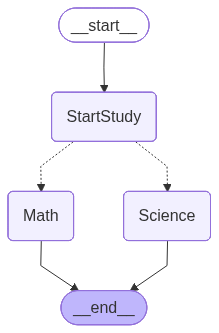

>>> StartStudy node triggered
>>> Math node triggered


{'student': 'Alice begins studying  Math', 'subject': 'Math'}

In [8]:
# ---------------------------------------------------------
# Cell 1: TypedDict State Schema (Math/Science)
# ---------------------------------------------------------
from typing_extensions import TypedDict
from typing import Literal
import random
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Define state schema
class SubjectState(TypedDict):
    student: str
    subject: Literal["Math", "Science"]

# Node functions
def start_study(state: SubjectState):
    print(">>> StartStudy node triggered")
    return {"student": state["student"] + " begins studying "}

def math_node(state: SubjectState):
    print(">>> Math node triggered")
    return {"student": state["student"] + " Math", "subject": "Math"}

def science_node(state: SubjectState):
    print(">>> Science node triggered")
    return {"student": state["student"] + " Science", "subject": "Science"}

# Conditional routing
def decide_subject(state: SubjectState) -> Literal["Math", "Science"]:
    return "Math" if random.random() < 0.5 else "Science"

# Build graph
builder = StateGraph(SubjectState)
builder.add_node("StartStudy", start_study)
builder.add_node("Math", math_node)
builder.add_node("Science", science_node)
builder.add_edge(START, "StartStudy")
builder.add_conditional_edges("StartStudy", decide_subject)
builder.add_edge("Math", END)
builder.add_edge("Science", END)

typed_graph = builder.compile()

# Visualize + Run
display(Image(typed_graph.get_graph().draw_mermaid_png()))
typed_graph.invoke({"student": "Alice"})

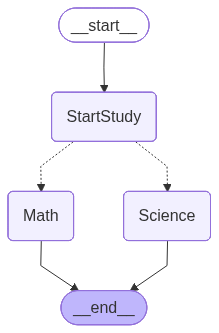

>>> StartStudy node triggered
>>> Science node triggered


{'student': 'Charlie begins studying  Science', 'subject': 'Science'}

In [9]:
# ---------------------------------------------------------
# Cell 2: DataClass State Schema (Math/Science)
# ---------------------------------------------------------
from dataclasses import dataclass

# Define state schema
@dataclass
class DataSubjectState:
    student: str
    subject: Literal["Math", "Science"]

# Node functions
def start_study(state: DataSubjectState):
    print(">>> StartStudy node triggered")
    return {"student": state.student + " begins studying "}

def math_node(state: DataSubjectState):
    print(">>> Math node triggered")
    return {"student": state.student + " Math", "subject": "Math"}

def science_node(state: DataSubjectState):
    print(">>> Science node triggered")
    return {"student": state.student + " Science", "subject": "Science"}

# Conditional routing
def decide_subject(state: DataSubjectState) -> Literal["Math", "Science"]:
    return "Math" if random.random() < 0.5 else "Science"

# Build graph
builder = StateGraph(DataSubjectState)
builder.add_node("StartStudy", start_study)
builder.add_node("Math", math_node)
builder.add_node("Science", science_node)
builder.add_edge(START, "StartStudy")
builder.add_conditional_edges("StartStudy", decide_subject)
builder.add_edge("Math", END)
builder.add_edge("Science", END)

data_graph = builder.compile()

# Visualize + Run
display(Image(data_graph.get_graph().draw_mermaid_png()))
data_graph.invoke(DataSubjectState(student="Charlie", subject="Math"))